# 🩺 Prediksi Penyakit Diabetes dengan Custom Deep Neural Network
**Elektronika Cerdas — Semester Gasal 2026/2027**
Departemen Teknik Elektro · FTEIC · Institut Teknologi Sepuluh Nopember

| | |
|---|---|
| **Nama** | *(isi nama lengkap)* |
| **NRP** | *(isi NRP)* |
| **Fase** | Fase I — Data Science & Pengembangan Model |

---

### Ringkasan Fase I
Notebook ini mengerjakan alur lengkap pengembangan model *Clinical Decision Support System* untuk
prediksi diabetes mellitus:

1. **Eksplorasi data (EDA)** — inspeksi dataset Kaggle 100.000 rekam medis (8 fitur + 1 target).
2. **Pembagian data** — Train/Validation/Test 70:15:15 dengan *Stratified Sampling*.
3. **Preprocessing tanpa kebocoran data** — transformer di-fit **hanya** pada data train.
4. **Penanganan class imbalance (3 teknik dikomparasi)** — class weighting `balanced`,
   **oversampling SMOTENC**, dan *decision threshold tuning*.
5. **Tiga percobaan custom MLP** — **Model A (Sigmoid)** vs **Model B (Softmax)** vs
   **Model C (Softmax + SMOTENC)** dengan variasi kedalaman, lebar, Dropout/BatchNormalization,
   dan learning rate berbeda.
6. **Evaluasi komprehensif** — Accuracy, Precision, Recall, F1-Score, Confusion Matrix, ROC & PR Curve.
7. **Ekspor artefak** — `model.keras` (model terbaik) dan `preprocessor.pkl` (scaler + encoder).


In [1]:
import os, json, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from pathlib import Path

# ===================== Konfigurasi Reproducibility =====================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# ---- Root folder proyek (robust terhadap lokasi eksekusi notebook) ----
ROOT = Path.cwd()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
FIG_DIR = ROOT / 'assets' / 'figures'
ART_DIR = ROOT / 'artifacts'
FIG_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

print('TensorFlow :', tf.__version__)
print('Pandas     :', pd.__version__)
print('Scikit-learn:', __import__('sklearn').__version__)
print('Imblearn   :', __import__('imblearn').__version__)
print('Folder figur:', FIG_DIR)


I0000 00:00:1791171911.963049    3912 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791171913.882985    3912 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.21.0
Pandas     : 3.0.6
Scikit-learn: 1.9.1
Imblearn   : 0.14.2
Folder figur: /home/user/DSEC_Diabetes_Prediction_Project/assets/figures


## 1. Memuat & Menginspeksi Dataset
Dataset publik Kaggle *Diabetes Prediction Dataset* (`diabetes_prediction_dataset.csv`):
100.000 sampel rekam medis dengan **8 fitur prediktor** dan **1 target biner** (`diabetes`).


In [2]:
DATA_PATH = ROOT / 'diabetes_prediction_dataset.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f'Jumlah sampel : {df_raw.shape[0]:,} baris')
print(f'Jumlah kolom  : {df_raw.shape[1]} (8 fitur + 1 target)')
df_raw.head()


Jumlah sampel : 100,000 baris
Jumlah kolom  : 9 (8 fitur + 1 target)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [4]:
print('=== Statistik deskriptif fitur numerik ===')
df_raw.describe().T.round(3)


=== Statistik deskriptif fitur numerik ===


,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.886,22.517,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.075,0.263,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039,0.195,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.321,6.637,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.528,1.071,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058,40.708,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085,0.279,0.00,0.00,0.00,0.00,1.00


In [5]:
print('=== Distribusi kategori: gender ===')
print(df_raw['gender'].value_counts().to_string())
print('\n=== Distribusi kategori: smoking_history (6 kategori unik) ===')
print(df_raw['smoking_history'].value_counts().to_string())


=== Distribusi kategori: gender ===
gender
Female    58552
Male      41430
Other        18

=== Distribusi kategori: smoking_history (6 kategori unik) ===
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004


## 2. Data Cleaning — Duplikat, Missing Value, dan Class Imbalance


In [6]:
n_dup = int(df_raw.duplicated().sum())
n_na  = int(df_raw.isna().sum().sum())
print(f'Baris duplikat sempurna            : {n_dup:,}')
print(f'Missing value (seluruh kolom)      : {n_na}')

# Buang duplikat agar model tidak menghafal sampel yang sama di train & test
df = df_raw.drop_duplicates().reset_index(drop=True).copy()
print(f'Ukuran dataset setelah pembersihan : {df.shape[0]:,} sampel')


Baris duplikat sempurna            : 3,854
Missing value (seluruh kolom)      : 0
Ukuran dataset setelah pembersihan : 96,146 sampel


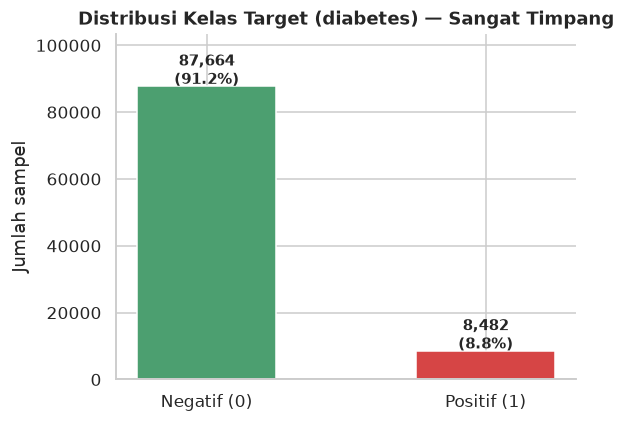

Rasio kelas Negatif : Positif = 10.34 : 1  ->  Accuracy Paradox mengintai!


In [7]:
# Distribusi kelas target -> tantangan class imbalance
counts = df['diabetes'].value_counts()
pct = df['diabetes'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(['Negatif (0)', 'Positif (1)'], counts.values, color=['#4C9F70', '#D64545'], width=0.5)
for b, c, p in zip(bars, counts.values, pct.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 800,
            f'{c:,}\n({p:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Distribusi Kelas Target (diabetes) — Sangat Timpang', fontweight='bold')
ax.set_ylabel('Jumlah sampel')
ax.set_ylim(0, counts.max() * 1.18)
sns.despine()
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_target_distribution.png', dpi=200)
plt.show()

ratio = counts[0] / counts[1]
print(f'Rasio kelas Negatif : Positif = {ratio:.2f} : 1  ->  Accuracy Paradox mengintai!')


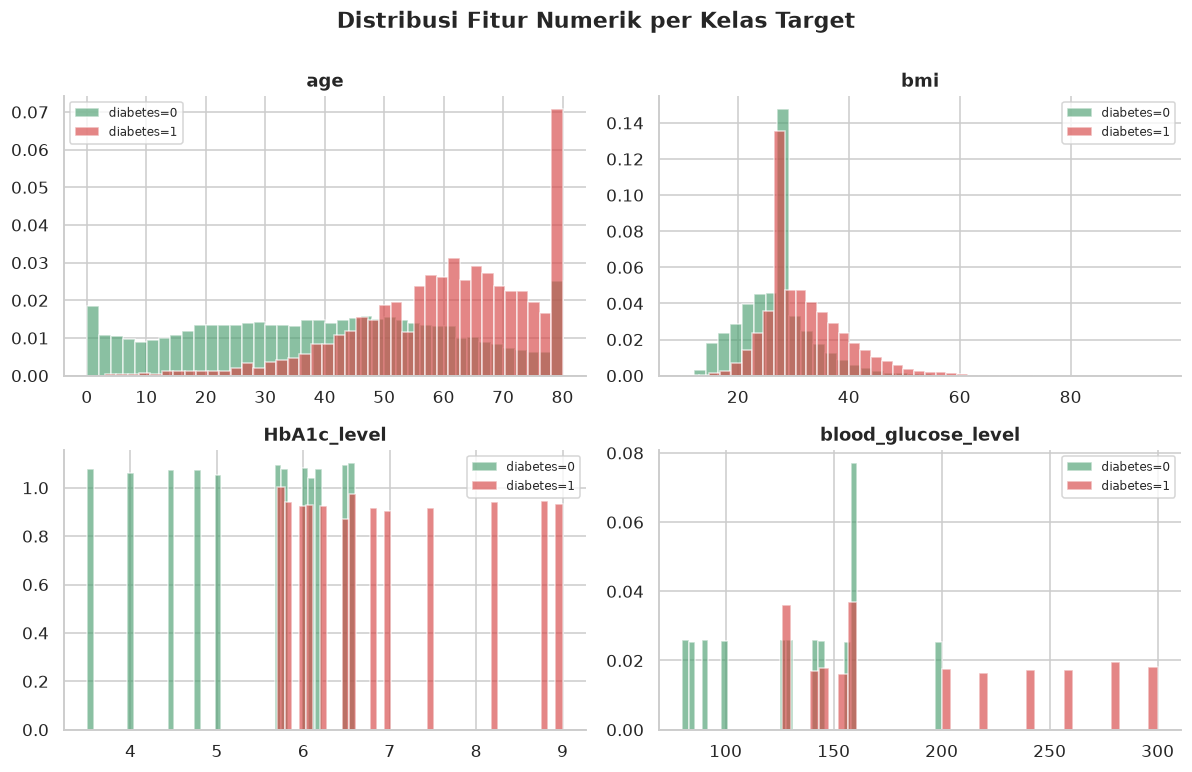

Terlihat jelas: HbA1c_level dan blood_glucose_level kelas positif bergeser jauh ke kanan.


In [8]:
# Distribusi fitur numerik terhadap kelas target
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), num_cols):
    for label, color in zip([0, 1], ['#4C9F70', '#D64545']):
        subset = df.loc[df['diabetes'] == label, col]
        ax.hist(subset, bins=40, alpha=0.65, color=color,
                label=f"diabetes={label}", density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)
fig.suptitle('Distribusi Fitur Numerik per Kelas Target', fontweight='bold', y=1.00)
sns.despine()
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_numeric_distributions.png', dpi=200, bbox_inches='tight')
plt.show()
print('Terlihat jelas: HbA1c_level dan blood_glucose_level kelas positif bergeser jauh ke kanan.')


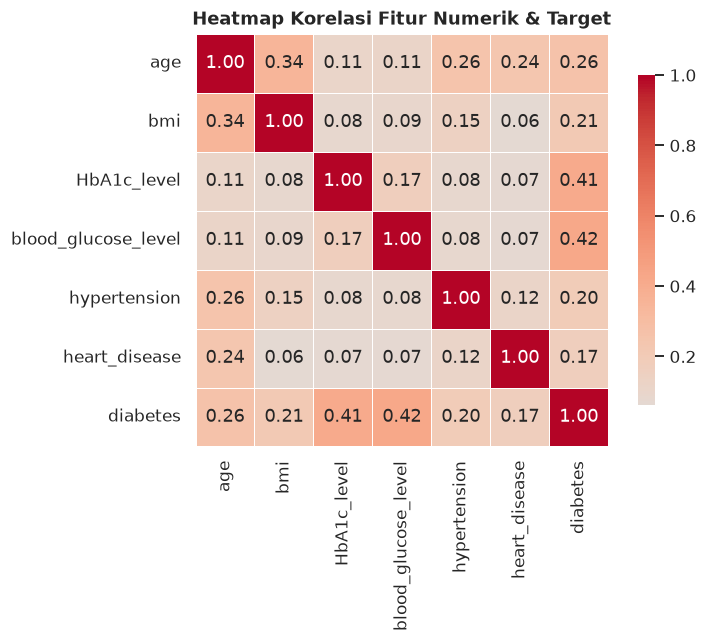

In [9]:
# Korelasi antar fitur numerik + target
fig, ax = plt.subplots(figsize=(7.5, 6))
corr = df[num_cols + ['hypertension', 'heart_disease', 'diabetes']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.6, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Heatmap Korelasi Fitur Numerik & Target', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_correlation_heatmap.png', dpi=200)
plt.show()


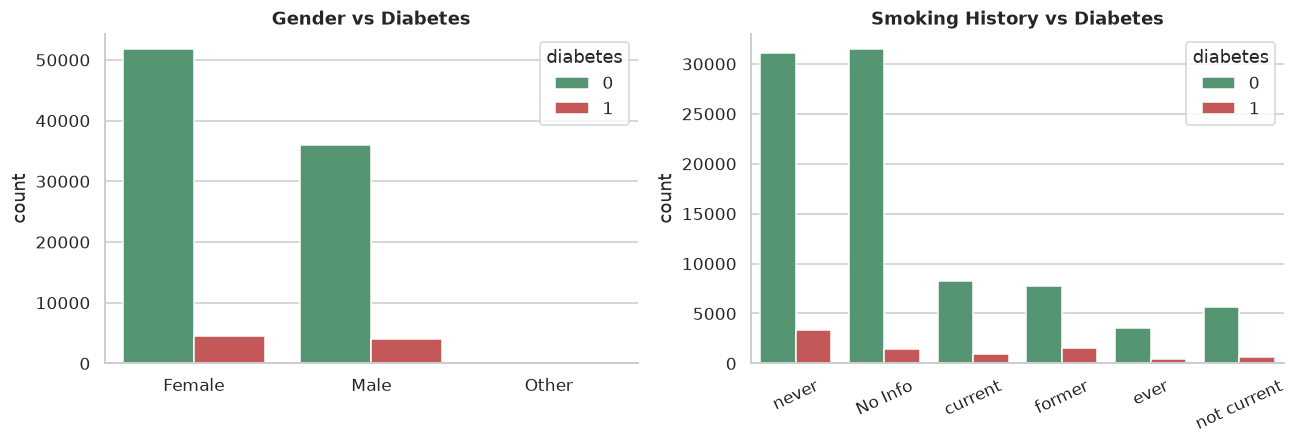

In [10]:
# Distribusi fitur kategorik terhadap target
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.countplot(data=df, x='gender', hue='diabetes', ax=axes[0],
              palette=['#4C9F70', '#D64545'], order=['Female', 'Male', 'Other'])
axes[0].set_title('Gender vs Diabetes', fontweight='bold')
axes[0].set_xlabel('')
sns.countplot(data=df, x='smoking_history', hue='diabetes', ax=axes[1],
              palette=['#4C9F70', '#D64545'])
axes[1].set_title('Smoking History vs Diabetes', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)
for a in axes:
    a.legend(title='diabetes')
sns.despine()
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_categorical_distribution.png', dpi=200)
plt.show()


## 3. Pembagian Data — Train / Validation / Test (70 : 15 : 15, Stratified)
Split dilakukan **sebelum** preprocessing apa pun. `stratify=y` memastikan proporsi kelas
8,5 % positif tetap terjaga di ketiga partisi.


In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diabetes'])
y = df['diabetes'].astype(int)

# Tahap 1: 70% train  |  30% sementara
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
# Tahap 2: belah sisa 30% menjadi 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f'Train      : {X_train.shape[0]:>6,} sampel ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Validation : {X_val.shape[0]:>6,} sampel ({X_val.shape[0]/len(df)*100:.1f}%)')
print(f'Test       : {X_test.shape[0]:>6,} sampel ({X_test.shape[0]/len(df)*100:.1f}%)')
print('\nProporsi kelas positif per partisi:')
pd.DataFrame({'Train': [y_train.mean()], 'Validation': [y_val.mean()], 'Test': [y_test.mean()]},
             index=['p(diabetes=1)']).T.round(4)


Train      : 67,302 sampel (70.0%)
Validation : 14,422 sampel (15.0%)
Test       : 14,422 sampel (15.0%)

Proporsi kelas positif per partisi:


,p(diabetes=1)
Train,0.0882
Validation,0.0883
Test,0.0882


## 4. Preprocessing — Tanpa Data Leakage 🔒
**Kaidah kritis:** seluruh transformer (`StandardScaler` + `OneHotEncoder`) di-fit
**hanya pada data Train**, lalu `transform` diterapkan pada Validation & Test.
Dengan demikian statistik train (mean/std, kategori) tidak pernah "bocor" ke data evaluasi.

| Fitur | Jenis | Perlakuan |
|---|---|---|
| `age`, `bmi`, `HbA1c_level`, `blood_glucose_level` | Numerik kontinu | `StandardScaler` |
| `hypertension`, `heart_disease` | Indikator biner | `StandardScaler` (ikut diskalakan agar stabil untuk MLP) |
| `gender` (3 kategori), `smoking_history` (6 kategori) | Kategorik | `OneHotEncoder(handle_unknown='ignore')` |


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NUM_FEATURES = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
CAT_FEATURES = ['gender', 'smoking_history']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
])

# >>> FIT HANYA PADA DATA TRAIN — titik kritis pencegahan data leakage <<<
preprocessor.fit(X_train)

X_train_pp = preprocessor.transform(X_train)
X_val_pp   = preprocessor.transform(X_val)
X_test_pp  = preprocessor.transform(X_test)

FEATURE_NAMES = preprocessor.get_feature_names_out().tolist()
print(f'Dimensi fitur model : {X_train_pp.shape[1]} '
      f'({len(NUM_FEATURES)} numerik + {len(FEATURE_NAMES) - len(NUM_FEATURES)} one-hot)')
print('Urutan fitur model  :')
for i, f in enumerate(FEATURE_NAMES):
    print(f'  [{i:>2}] {f}')


Dimensi fitur model : 15 (6 numerik + 9 one-hot)
Urutan fitur model  :
  [ 0] num__age
  [ 1] num__hypertension
  [ 2] num__heart_disease
  [ 3] num__bmi
  [ 4] num__HbA1c_level
  [ 5] num__blood_glucose_level
  [ 6] cat__gender_Female
  [ 7] cat__gender_Male
  [ 8] cat__gender_Other
  [ 9] cat__smoking_history_No Info
  [10] cat__smoking_history_current
  [11] cat__smoking_history_ever
  [12] cat__smoking_history_former
  [13] cat__smoking_history_never
  [14] cat__smoking_history_not current


## 5. Penanganan Class Imbalance — Class Weighting
Alih-alih mengandalkan akurasi (Accuracy Paradox 91,5 %), model diberi pembobotan kelas
`balanced`: kelas minoritas (positif) menerima bobot ≈ 10× lebih besar sehingga
*False Negative* — yang fatal secara klinis — dihukum lebih berat oleh loss.
(Nantinya pada percobaan Model C, teknik ini dikomparasi dengan **oversampling SMOTENC**.)


In [13]:
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train.to_numpy())
CLASS_WEIGHTS = {0: float(cw[0]), 1: float(cw[1])}
print(f'Bobot kelas Negatif (0) : {CLASS_WEIGHTS[0]:.4f}')
print(f'Bobot kelas Positif (1) : {CLASS_WEIGHTS[1]:.4f}')


Bobot kelas Negatif (0) : 0.5484
Bobot kelas Positif (1) : 5.6680


## 6. Model A — Arsitektur Sigmoid (Opsi A)
`Input(15) → Dense(64, ReLU) → Dropout(0.30) → Dense(32, ReLU) → Dropout(0.20) → Dense(1, Sigmoid)`

- **Output:** 1 neuron, aktivasi sigmoid $\sigma(z)=\frac{1}{1+e^{-z}}\in[0,1]$ → probabilitas $P(\text{diabetes})$.
- **Loss:** `binary_crossentropy`  $L_{BCE}=-\big[y\ln\hat y+(1-y)\ln(1-\hat y)\big]$.
- **Label target:** skalar integer $y\in\{0,1\}$.
- **Optimizer:** Adam, learning rate awal **1e-3** + `ReduceLROnPlateau`.
- **Regularisasi:** Dropout 0.30 / 0.20.


In [14]:
def build_model_a(n_features: int) -> tf.keras.Model:
    inp = tf.keras.Input(shape=(n_features,), name='clinical_input')
    x = tf.keras.layers.Dense(64, activation='relu', name='dense_64')(inp)
    x = tf.keras.layers.Dropout(0.30, name='dropout_030')(x)
    x = tf.keras.layers.Dense(32, activation='relu', name='dense_32')(x)
    x = tf.keras.layers.Dropout(0.20, name='dropout_020')(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid', name='output_sigmoid')(x)
    model = tf.keras.Model(inp, out, name='Model_A_Sigmoid')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_a = build_model_a(X_train_pp.shape[1])
model_a.summary()


Model: "Model_A_Sigmoid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ clinical_input (InputLayer)     │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_030 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_020 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_sigmoid (Dense)          │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
callbacks_a = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True,
                                     verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                         min_lr=1e-5, verbose=1),
]

history_a = model_a.fit(
    X_train_pp, y_train.to_numpy(),
    validation_data=(X_val_pp, y_val.to_numpy()),
    epochs=60, batch_size=1024, verbose=2,
    class_weight=CLASS_WEIGHTS, callbacks=callbacks_a,
)


Epoch 1/60


66/66 - 1s - 19ms/step - accuracy: 0.7439 - loss: 0.4727 - val_accuracy: 0.8474 - val_loss: 0.3205 - learning_rate: 0.0010


Epoch 2/60


66/66 - 1s - 8ms/step - accuracy: 0.8628 - loss: 0.2880 - val_accuracy: 0.8595 - val_loss: 0.2871 - learning_rate: 0.0010


Epoch 3/60


...

Epoch 59/60



Epoch 59: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.


66/66 - 0s - 4ms/step - accuracy: 0.8959 - loss: 0.1875 - val_accuracy: 0.8847 - val_loss: 0.1944 - learning_rate: 3.1250e-05


Epoch 59: early stopping


Restoring model weights from the end of the best epoch: 52.


## 7. Model B — Arsitektur Softmax (Opsi B)
`Input(15) → Dense(128, ReLU) → BatchNorm → Dropout(0.30) → Dense(64, ReLU) → BatchNorm → Dropout(0.25) → Dense(32, ReLU) → Dense(2, Softmax)`

- **Output:** 2 neuron, softmax $P(y=i\mid z)=\dfrac{e^{z_i}}{\sum_{j=1}^{2}e^{z_j}}$ → distribusi $(P_0, P_1)$.
- **Loss:** `categorical_crossentropy`  $L_{CCE}=-\sum_{i=1}^{2} y_i\ln\hat y_i$.
- **Label target:** one-hot encoded $y\in\{[1,0],[0,1]\}$ (`to_categorical`).
- **Optimizer:** Adam, learning rate awal **5e-4** (lebih kecil, arsitektur lebih dalam).
- **Regularisasi:** Batch Normalization + Dropout 0.30 / 0.25 → arsitektur **lebih dalam & lebih lebar** dari Model A.
- **Imbalance:** karena label one-hot, pembobotan kelas diberikan lewat `sample_weight`
  (ekuivalen matematis dengan `class_weight`).


In [16]:
def build_model_b(n_features: int) -> tf.keras.Model:
    inp = tf.keras.Input(shape=(n_features,), name='clinical_input')
    x = tf.keras.layers.Dense(128, activation='relu', name='dense_128')(inp)
    x = tf.keras.layers.BatchNormalization(name='batchnorm_1')(x)
    x = tf.keras.layers.Dropout(0.30, name='dropout_030')(x)
    x = tf.keras.layers.Dense(64, activation='relu', name='dense_64')(x)
    x = tf.keras.layers.BatchNormalization(name='batchnorm_2')(x)
    x = tf.keras.layers.Dropout(0.25, name='dropout_025')(x)
    x = tf.keras.layers.Dense(32, activation='relu', name='dense_32')(x)
    out = tf.keras.layers.Dense(2, activation='softmax', name='output_softmax')(x)
    model = tf.keras.Model(inp, out, name='Model_B_Softmax')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_b = build_model_b(X_train_pp.shape[1])
model_b.summary()


Model: "Model_B_Softmax"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ clinical_input (InputLayer)     │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_030 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_025 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,218 (51.63 KB)

 Trainable params: 12,834 (50.13 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
# Label one-hot + bobot sampel (kelas positif berbobot ~10x)
y_train_oh = tf.keras.utils.to_categorical(y_train.to_numpy(), num_classes=2)
y_val_oh   = tf.keras.utils.to_categorical(y_val.to_numpy(), num_classes=2)
sw_train   = np.where(y_train.to_numpy() == 1, CLASS_WEIGHTS[1], CLASS_WEIGHTS[0])
sw_val     = np.where(y_val.to_numpy() == 1, CLASS_WEIGHTS[1], CLASS_WEIGHTS[0])

callbacks_b = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True,
                                     verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                         min_lr=1e-5, verbose=1),
]

history_b = model_b.fit(
    X_train_pp, y_train_oh,
    validation_data=(X_val_pp, y_val_oh, sw_val),
    epochs=60, batch_size=1024, verbose=2,
    sample_weight=sw_train, callbacks=callbacks_b,
)


Epoch 1/60


66/66 - 2s - 33ms/step - accuracy: 0.6976 - loss: 0.4639 - val_accuracy: 0.9491 - val_loss: 0.4350 - learning_rate: 5.0000e-04


Epoch 2/60


66/66 - 1s - 8ms/step - accuracy: 0.8581 - loss: 0.2943 - val_accuracy: 0.9443 - val_loss: 0.3639 - learning_rate: 5.0000e-04


Epoch 3/60


...

Epoch 59/60



Epoch 59: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.


66/66 - 1s - 8ms/step - accuracy: 0.8948 - loss: 0.1879 - val_accuracy: 0.8907 - val_loss: 0.2043 - learning_rate: 3.1250e-05


Epoch 59: early stopping


Restoring model weights from the end of the best epoch: 52.


## 7.5 Eksperimen Mitigasi Imbalance Alternatif — Model C: Softmax + **SMOTENC**
Selain pembobotan kelas, teknik mitigasi populer lain adalah **oversampling sintetis**.
Percobaan ini memakai **SMOTENC** (varian SMOTE untuk data campuran numerik–kategorik)
untuk mengoversampling kelas minoritas pada data train hingga seimbang, lalu melatih
arsitektur softmax yang identik dengan Model B **tanpa** class weighting — sehingga
peran masing-masing teknik mitigasi dapat dibandingkan secara adil.

> ⚠️ **Kaidah anti-leakage:** `fit_resample` dijalankan **SETELAH split** dan **HANYA pada
> data train**. Bila SMOTE dijalankan sebelum split, sampel sintetis (interpolasi antar
> sampel asli) akan bocor ke Validation/Test dan menggelembungkan metrik secara palsu.


In [18]:
from imblearn.over_sampling import SMOTENC

# Indeks kolom kategorik pada X (dipakai SMOTENC agar kategori disintesis dengan benar)
cat_idx = [X.columns.get_loc(c) for c in CAT_FEATURES]

smotenc = SMOTENC(categorical_features=cat_idx, random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smotenc.fit_resample(X_train, y_train)   # HANYA train!

print(f'Sebelum SMOTE : {len(X_train):>7,} sampel  (positif {int(y_train.sum()):,})')
print(f'Setelah SMOTE : {len(X_train_sm):>7,} sampel  (positif {int(y_train_sm.sum()):,})')

# Transformasi dengan preprocessor yang SUDAH di-fit pada train asli (tanpa fit ulang!)
X_train_sm_pp = preprocessor.transform(X_train_sm)
y_train_sm_oh = tf.keras.utils.to_categorical(y_train_sm.to_numpy(), num_classes=2)


Sebelum SMOTE :  67,302 sampel  (positif 5,937)
Setelah SMOTE : 122,730 sampel  (positif 61,365)


In [19]:
# Model C: arsitektur identik Model B, dilatih pada train hasil SMOTENC, TANPA class weight
model_c = build_model_b(X_train_sm_pp.shape[1])
model_c.name = 'Model_C_Softmax_SMOTENC'

callbacks_c = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True,
                                     verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                         min_lr=1e-5, verbose=1),
]

history_c = model_c.fit(
    X_train_sm_pp, y_train_sm_oh,
    validation_data=(X_val_pp, y_val_oh),        # validasi asli (tanpa bobot) agar objektif
    epochs=60, batch_size=1024, verbose=2,
    callbacks=callbacks_c,
)


Epoch 1/60


120/120 - 3s - 21ms/step - accuracy: 0.8419 - loss: 0.3456 - val_accuracy: 0.8045 - val_loss: 0.3975 - learning_rate: 5.0000e-04


Epoch 2/60


120/120 - 1s - 9ms/step - accuracy: 0.8880 - loss: 0.2446 - val_accuracy: 0.8610 - val_loss: 0.2844 - learning_rate: 5.0000e-04


Epoch 3/60


...

120/120 - 1s - 10ms/step - accuracy: 0.9144 - loss: 0.1745 - val_accuracy: 0.8882 - val_loss: 0.1937 - learning_rate: 1.2500e-04


Epoch 35/60


120/120 - 1s - 11ms/step - accuracy: 0.9155 - loss: 0.1737 - val_accuracy: 0.8882 - val_loss: 0.1939 - learning_rate: 6.2500e-05


Epoch 35: early stopping


Restoring model weights from the end of the best epoch: 28.


## 8. Evaluasi — Ambang Batas, Metrik Klinis, Confusion Matrix, ROC & PR Curve

> **Mengapa tidak cukup akurasi?** Model naif yang selalu memprediksi 0 sudah meraih
> akurasi ≈ 91,5 % tetapi gagal total mendeteksi pasien diabetes (Accuracy Paradox).
> Metrik wajib: **Recall/Sensitivitas** (menghindari False Negative fatal), Precision,
> F1-Score, dan Confusion Matrix.

Selain itu dilakukan **decision threshold tuning**: ambang klasifikasi $\theta$ dioptimalkan
pada **data Validation** (bukan Test!) dengan memaksimalkan F1 kelas positif,
lalu diterapkan pada Test set.


In [20]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)

def prob_positive(model, X, mode: str) -> np.ndarray:
    # Ambil P(diabetes=1) dari kedua jenis output layer
    raw = np.asarray(model.predict(X, verbose=0))
    return raw.ravel() if mode == 'sigmoid' else raw[:, 1]

def evaluate(y_true, proba, threshold: float) -> dict:
    pred = (proba >= threshold).astype(int)
    return {
        'Accuracy' : accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall'   : recall_score(y_true, pred, zero_division=0),
        'F1_Score' : f1_score(y_true, pred, zero_division=0),
    }

def tune_threshold(y_true, proba):
    # Sweep theta pada data VALIDATION, pilih F1 kelas positif terbaik
    grid = np.arange(0.10, 0.901, 0.01)
    f1s = np.array([f1_score(y_true, (proba >= t).astype(int), zero_division=0) for t in grid])
    best = int(np.argmax(f1s))
    return float(grid[best]), float(f1s[best]), grid, f1s

# ---- Registry tiga percobaan ----
MODELS = {
    'Model A (Sigmoid)'       : (model_a, 'sigmoid', history_a),
    'Model B (Softmax)'       : (model_b, 'softmax', history_b),
    'Model C (Softmax+SMOTE)' : (model_c, 'softmax', history_c),
}
COLORS = {'Model A (Sigmoid)': '#1F77B4',
          'Model B (Softmax)': '#FF7F0E',
          'Model C (Softmax+SMOTE)': '#2CA02C'}

y_val_np, y_test_np = y_val.to_numpy(), y_test.to_numpy()

proba_val, proba_test, thr, thr_grid, thr_f1 = {}, {}, {}, {}, {}
for name, (m, mode, _) in MODELS.items():
    proba_val[name]  = prob_positive(m, X_val_pp, mode)
    proba_test[name] = prob_positive(m, X_test_pp, mode)
    thr[name], f1v, thr_grid[name], thr_f1[name] = tune_threshold(y_val_np, proba_val[name])
    print(f'{name:<24}: theta optimal = {thr[name]:.2f}   (F1 val = {f1v:.4f})')


Model A (Sigmoid)       : theta optimal = 0.86   (F1 val = 0.7897)


Model B (Softmax)       : theta optimal = 0.85   (F1 val = 0.7901)


Model C (Softmax+SMOTE) : theta optimal = 0.90   (F1 val = 0.7879)


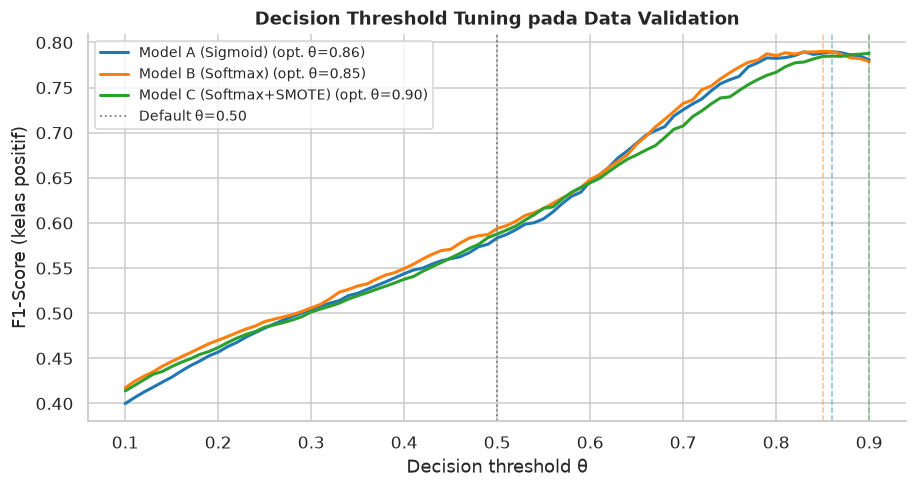

In [21]:
# Visualisasi sweep ambang batas (F1 vs theta) pada data Validation
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for name in MODELS:
    ax.plot(thr_grid[name], thr_f1[name], lw=2, color=COLORS[name],
            label=f'{name} (opt. θ={thr[name]:.2f})')
    ax.axvline(thr[name], color=COLORS[name], ls='--', lw=1, alpha=0.5)
ax.axvline(0.5, color='gray', ls=':', lw=1.2, label='Default θ=0.50')
ax.set_xlabel('Decision threshold θ')
ax.set_ylabel('F1-Score (kelas positif)')
ax.set_title('Decision Threshold Tuning pada Data Validation', fontweight='bold')
ax.legend(fontsize=9)
sns.despine()
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_threshold_sweep.png', dpi=200)
plt.show()


In [22]:
# ===== Evaluasi final pada TEST SET (tidak pernah tersentuh saat tuning) =====
cols = []
for name in MODELS:
    cols += [f'{name} θ=0.50', f'{name} θ=opt']
eval_test = pd.DataFrame(
    {f'{name} θ=0.50': evaluate(y_test_np, proba_test[name], 0.50) for name in MODELS} |
    {f'{name} θ=opt' : evaluate(y_test_np, proba_test[name], thr[name]) for name in MODELS}
).round(4)

auc, ap = {}, {}
for name in MODELS:
    auc[name] = roc_auc_score(y_test_np, proba_test[name])
    ap[name]  = average_precision_score(y_test_np, proba_test[name])
eval_test.loc['ROC_AUC']    = [v for name in MODELS for v in (auc[name], auc[name])]
eval_test.loc['PR_AUC(AP)'] = [v for name in MODELS for v in (ap[name], ap[name])]

print('=== Tabel Metrik Klinis pada TEST SET ===')
eval_test.round(4)


=== Tabel Metrik Klinis pada TEST SET ===


,Model A (Sigmoid) θ=0.50,Model B (Softmax) θ=0.50,Model C (Softmax+SMOTE) θ=0.50,Model A (Sigmoid) θ=opt,Model B (Softmax) θ=opt,Model C (Softmax+SMOTE) θ=opt
Accuracy,0.8954,0.8981,0.8987,0.9709,0.9724,0.9714
Precision,0.4544,0.4611,0.4616,0.9410,0.9740,0.9778
Recall,0.9237,0.9167,0.8923,0.7146,0.7060,0.6918
F1_Score,0.6091,0.6135,0.6084,0.8123,0.8186,0.8103
ROC_AUC,0.9773,0.9773,0.9772,0.9772,0.9737,0.9737
PR_AUC(AP),0.8847,0.8847,0.8840,0.8840,0.8728,0.8728


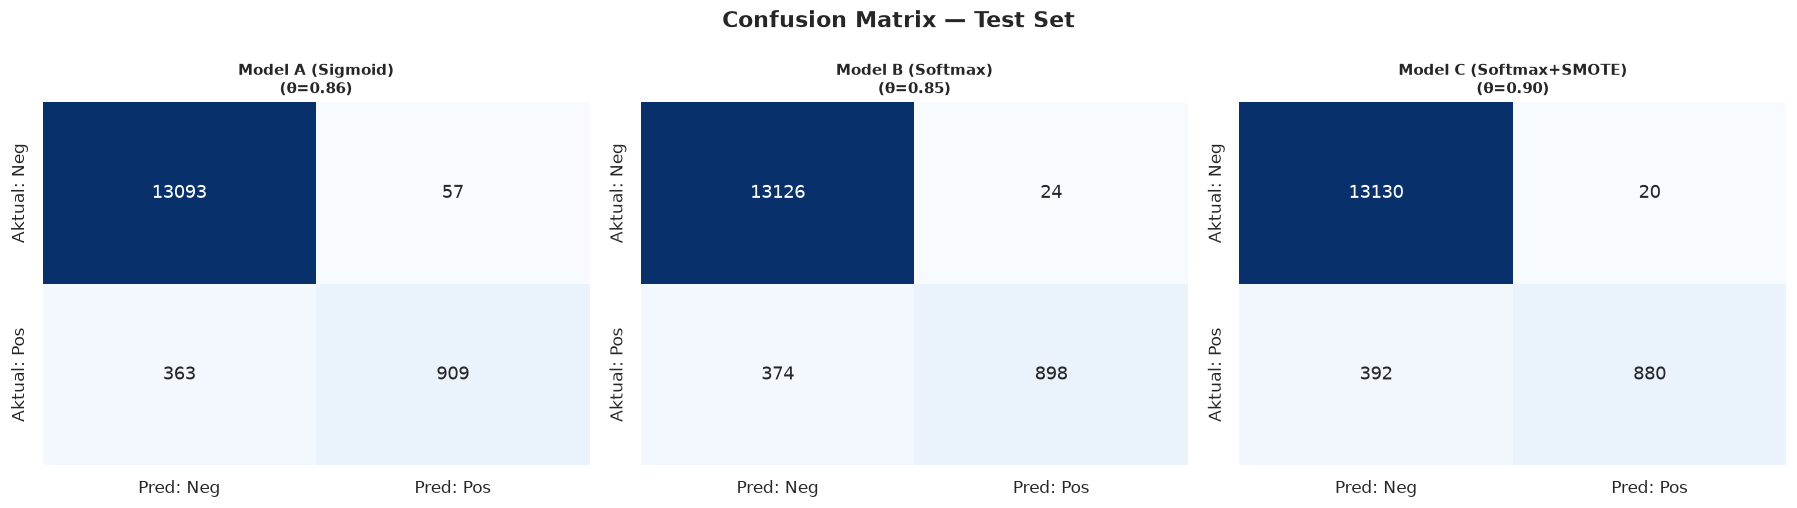

Model A (Sigmoid)        -> TN=13,093 FP=57 FN=363 TP=909
Model B (Softmax)        -> TN=13,126 FP=24 FN=374 TP=898
Model C (Softmax+SMOTE)  -> TN=13,130 FP=20 FN=392 TP=880


In [23]:
# Confusion Matrix ketiga model (ambang optimal hasil tuning)
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.7))
cms = {}
for ax, name in zip(axes, MODELS):
    cm = confusion_matrix(y_test_np, (proba_test[name] >= thr[name]).astype(int))
    cms[name] = cm
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Neg', 'Pred: Pos'],
                yticklabels=['Aktual: Neg', 'Aktual: Pos'],
                annot_kws={'size': 12}, cbar=False)
    ax.set_title(f'{name}\n(θ={thr[name]:.2f})', fontweight='bold', fontsize=10)
    ax.set_ylabel('')
fig.suptitle('Confusion Matrix — Test Set', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_confusion_matrix.png', dpi=200)
plt.show()

for name in MODELS:
    cm = cms[name]
    print(f"{name:<24} -> TN={cm[0,0]:,} FP={cm[0,1]:,} FN={cm[1,0]:,} TP={cm[1,1]:,}")


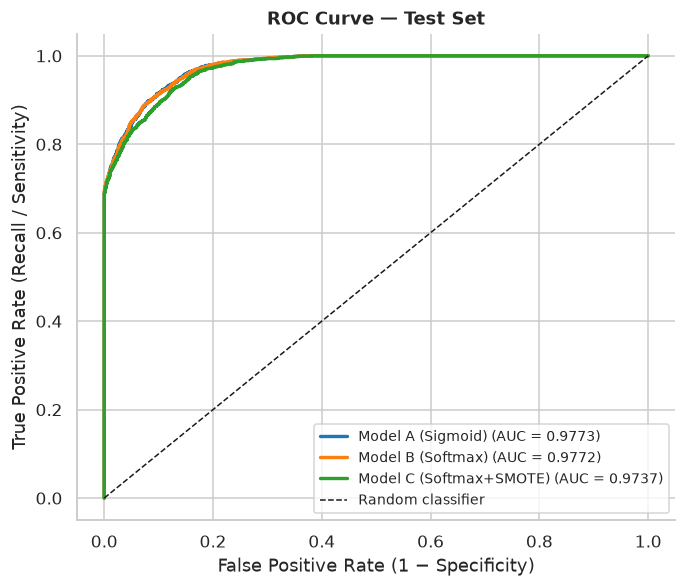

In [24]:
# ROC Curve ketiga model pada Test Set
fig, ax = plt.subplots(figsize=(6.4, 5.5))
for name in MODELS:
    fpr, tpr, _ = roc_curve(y_test_np, proba_test[name])
    ax.plot(fpr, tpr, lw=2.2, color=COLORS[name], label=f'{name} (AUC = {auc[name]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate (1 − Specificity)')
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)')
ax.set_title('ROC Curve — Test Set', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
sns.despine()
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_roc_curve.png', dpi=200)
plt.show()


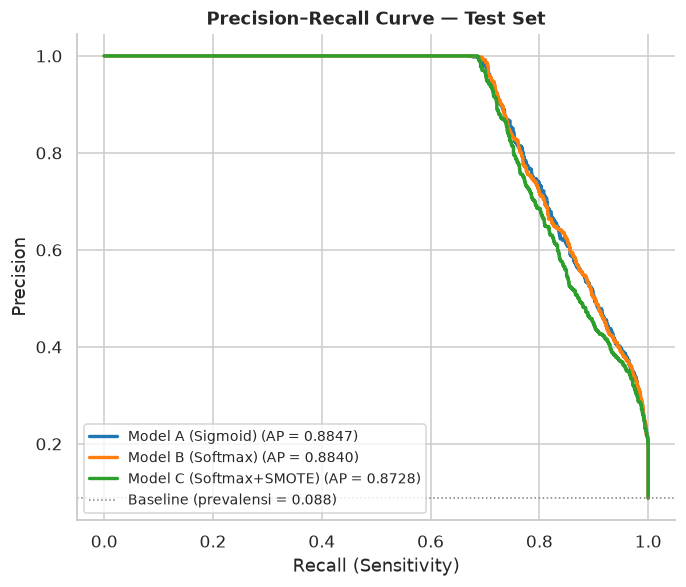

In [25]:
# Precision-Recall Curve (lebih informatif untuk kelas imbang)
fig, ax = plt.subplots(figsize=(6.4, 5.5))
for name in MODELS:
    pr, rc, _ = precision_recall_curve(y_test_np, proba_test[name])
    ax.plot(rc, pr, lw=2.2, color=COLORS[name], label=f'{name} (AP = {ap[name]:.4f})')
ax.axhline(y_test_np.mean(), color='gray', ls=':', lw=1,
           label=f"Baseline (prevalensi = {y_test_np.mean():.3f})")
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curve — Test Set', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
sns.despine()
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_pr_curve.png', dpi=200)
plt.show()


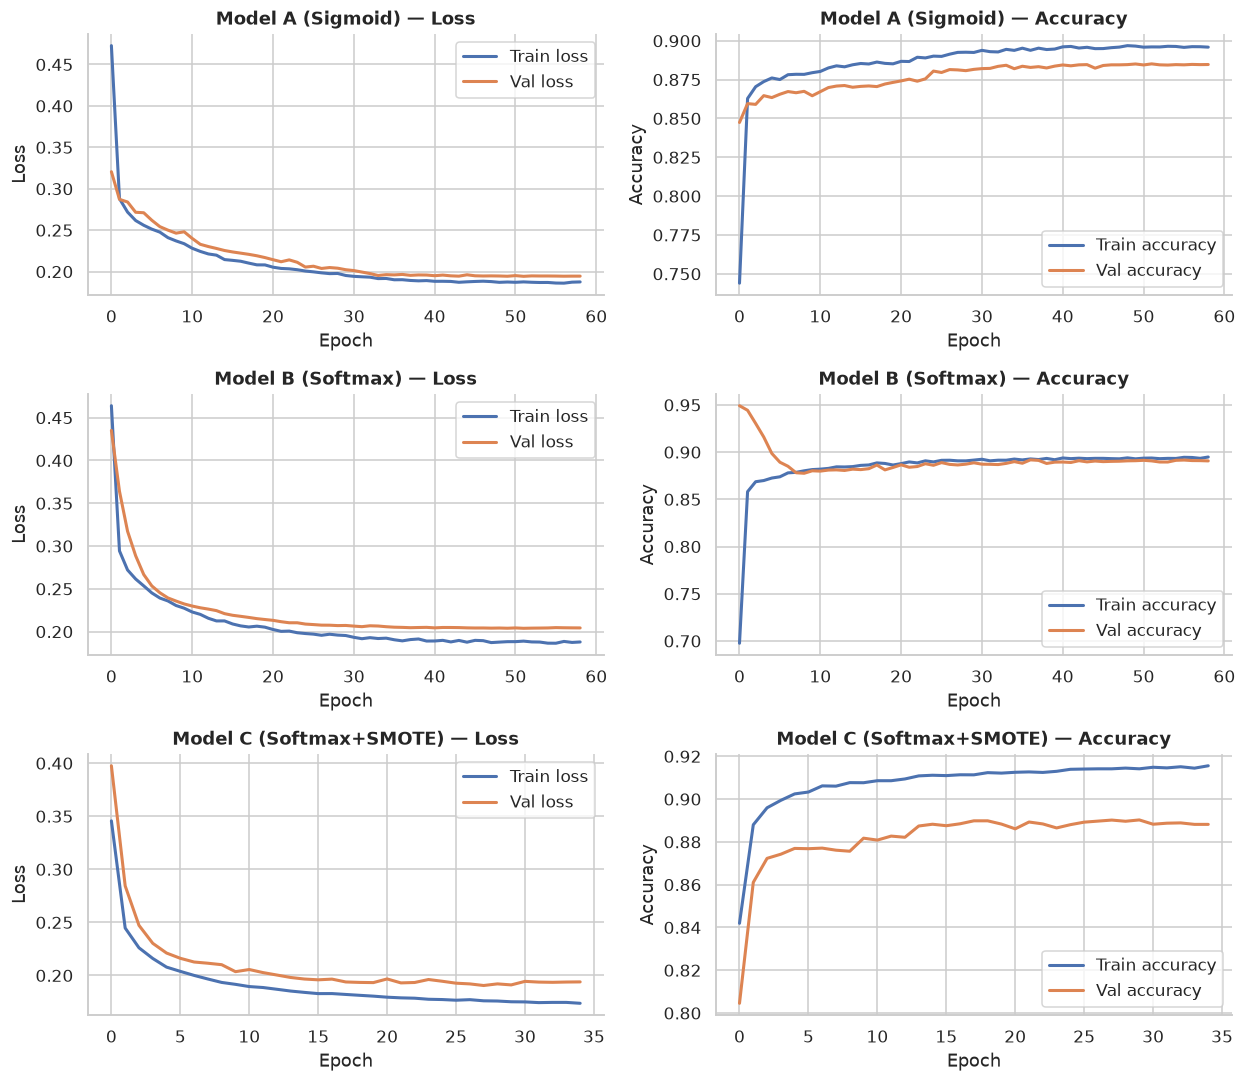

In [26]:
# Kurva sejarah pelatihan (loss & akurasi) ketiga model
fig, axes = plt.subplots(3, 2, figsize=(11.5, 10))
for row, name in enumerate(MODELS):
    hist = MODELS[name][2].history
    axl, axa = axes[row]
    axl.plot(hist['loss'], lw=2, label='Train loss')
    axl.plot(hist['val_loss'], lw=2, label='Val loss')
    axl.set_title(f'{name} — Loss', fontweight='bold')
    axl.set_xlabel('Epoch'); axl.set_ylabel('Loss'); axl.legend()
    axa.plot(hist['accuracy'], lw=2, label='Train accuracy')
    axa.plot(hist['val_accuracy'], lw=2, label='Val accuracy')
    axa.set_title(f'{name} — Accuracy', fontweight='bold')
    axa.set_xlabel('Epoch'); axa.set_ylabel('Accuracy'); axa.legend()
sns.despine()
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_training_history.png', dpi=200)
plt.show()


## 9. Seleksi Model Terbaik & Ekspor Artefak
Model terbaik dipilih berdasarkan **F1-Score kelas positif** pada Test Set dengan ambang
optimal (metrik yang paling relevan secara klinis untuk data timpang), dengan ROC-AUC
sebagai pembanding. Artefak yang diekspor:

1. `artifacts/model.keras` — bobot model terbaik (siap dipakai GUI).
2. `artifacts/preprocessor.pkl` — `ColumnTransformer` (scaler + encoder), urutan fitur,
   dan ambang optimal → menjamin transformasi GUI **identik** dengan proses training.
3. `artifacts/training_history.json` — riwayat training & metrik untuk dokumentasi laporan.


In [27]:
print(f"{'Model':<26}{'F1 (θ=opt)':>12}{'ROC-AUC':>10}{'θ*':>7}")
for name in MODELS:
    f1o = eval_test.loc['F1_Score', f'{name} θ=opt']
    print(f'{name:<26}{f1o:>12.4f}{auc[name]:>10.4f}{thr[name]:>7.2f}')

# Seleksi: maksimalkan F1 kelas positif, tie-break ROC-AUC
best_name = max(MODELS, key=lambda n: (eval_test.loc['F1_Score', f'{n} θ=opt'], auc[n]))
best_model, best_mode, _ = MODELS[best_name]
best_thr = thr[best_name]
print(f'\n>>> Model terbaik terpilih : {best_name}')
print(f'>>> Ambang keputusan (θ)   : {best_thr:.2f}')


Model                       F1 (θ=opt)   ROC-AUC     θ*
Model A (Sigmoid)               0.8123    0.9773   0.86
Model B (Softmax)               0.8186    0.9772   0.85
Model C (Softmax+SMOTE)         0.8103    0.9737   0.90

>>> Model terbaik terpilih : Model B (Softmax)
>>> Ambang keputusan (θ)   : 0.85


In [28]:
# ---------- Simpan model terbaik ----------
MODEL_PATH = ART_DIR / 'model.keras'
best_model.save(MODEL_PATH)
print('Model tersimpan      :', MODEL_PATH)

# ---------- Simpan preprocessor + metadata ----------
PREPROC_PATH = ART_DIR / 'preprocessor.pkl'
payload = {
    'preprocessor'        : preprocessor,            # StandardScaler + OneHotEncoder (fit pada train)
    'feature_names'       : FEATURE_NAMES,
    'numeric_features'    : NUM_FEATURES,
    'categorical_features': CAT_FEATURES,
    'optimal_threshold'   : best_thr,
    'default_threshold'   : 0.5,
    'best_model_name'     : best_name,
    'output_mode'         : best_mode,               # 'sigmoid' | 'softmax'
    'target_name'         : 'diabetes',
    'seed'                : SEED,
}
joblib.dump(payload, PREPROC_PATH)
print('Preprocessor tersimpan:', PREPROC_PATH)

# ---------- Simpan riwayat & metrik untuk laporan ----------
def hist_to_json(h):
    return {k: [float(v) for v in vals] for k, vals in h.history.items()}

history_payload = {
    'seed': SEED,
    'class_weights': CLASS_WEIGHTS,
    'thresholds': {**{n: thr[n] for n in MODELS}, 'selected': best_thr, 'default': 0.5},
    'best_model': best_name,
    'model_a': hist_to_json(history_a),
    'model_b': hist_to_json(history_b),
    'model_c': hist_to_json(history_c),
    'test_metrics': {c: {str(i): float(v) for i, v in eval_test[c].items()} for c in eval_test.columns},
    'auc': {k: float(v) for k, v in auc.items()},
    'ap': {k: float(v) for k, v in ap.items()},
    'confusion_matrices': {n: cms[n].tolist() for n in MODELS},
}
with open(ART_DIR / 'training_history.json', 'w') as f:
    json.dump(history_payload, f, indent=2)
print('Riwayat tersimpan    :', ART_DIR / 'training_history.json')


Model tersimpan      : /home/user/DSEC_Diabetes_Prediction_Project/artifacts/model.keras
Preprocessor tersimpan: /home/user/DSEC_Diabetes_Prediction_Project/artifacts/preprocessor.pkl
Riwayat tersimpan    : /home/user/DSEC_Diabetes_Prediction_Project/artifacts/training_history.json


## 10. Uji Integrasi — Simulasi Fase III (GUI Backend)
Verifikasi end-to-end: muat ulang `model.keras` + `preprocessor.pkl` dari disk,
transformasi dua pasien contoh (sehat vs berisiko tinggi), lalu jalankan inferensi.
Logika ini **identik** dengan yang dipakai aplikasi desktop `src/app.py`.


In [29]:
loaded_model = tf.keras.models.load_model(ART_DIR / 'model.keras')
loaded_pp    = joblib.load(ART_DIR / 'preprocessor.pkl')

sample_patients = pd.DataFrame([
    {'gender': 'Female', 'age': 27.0, 'hypertension': 0, 'heart_disease': 0,
     'smoking_history': 'never',   'bmi': 21.5, 'HbA1c_level': 5.0, 'blood_glucose_level':  95},
    {'gender': 'Male',   'age': 58.0, 'hypertension': 1, 'heart_disease': 0,
     'smoking_history': 'current', 'bmi': 32.4, 'HbA1c_level': 7.8, 'blood_glucose_level': 210},
])

X_sample = loaded_pp['preprocessor'].transform(sample_patients)
p_sample = np.asarray(loaded_model.predict(X_sample, verbose=0))
p_sample = p_sample.ravel() if loaded_pp['output_mode'] == 'sigmoid' else p_sample[:, 1]
thr_loaded = loaded_pp['optimal_threshold']

for rec, p in zip(sample_patients.to_dict('records'), p_sample):
    status = 'POSITIF Diabetes' if p >= thr_loaded else 'NEGATIF (Non-Diabetic)'
    conf = p if p >= thr_loaded else 1.0 - p
    print(f"P(diabetes) = {p:.4f} | confidence = {conf:.4f} -> {status}")
    print(f"   pasien: {rec}")
print('\nIntegrasi backend OK — artefak siap dipakai GUI desktop (Fase II & III).')


P(diabetes) = 0.0005 | confidence = 0.9995 -> NEGATIF (Non-Diabetic)
   pasien: {'gender': 'Female', 'age': 27.0, 'hypertension': 0, 'heart_disease': 0, 'smoking_history': 'never', 'bmi': 21.5, 'HbA1c_level': 5.0, 'blood_glucose_level': 95}
P(diabetes) = 1.0000 | confidence = 1.0000 -> POSITIF Diabetes
   pasien: {'gender': 'Male', 'age': 58.0, 'hypertension': 1, 'heart_disease': 0, 'smoking_history': 'current', 'bmi': 32.4, 'HbA1c_level': 7.8, 'blood_glucose_level': 210}

Integrasi backend OK — artefak siap dipakai GUI desktop (Fase II & III).


## Kesimpulan Fase I
- Dataset 100.000 rekam medis dibersihkan (duplikat dibuang) lalu dibagi **70/15/15 stratified**.
- Seluruh transformer di-fit **hanya pada data train** → tidak ada data leakage.
- Class imbalance ditangani & dikomparasi dengan tiga teknik: **class weighting balanced**,
  **oversampling SMOTENC** (hanya pada train, setelah split), dan **tuning ambang keputusan**.
- Tiga percobaan custom MLP (Sigmoid vs Softmax vs Softmax+SMOTE) dilatih dan dibandingkan
  secara menyeluruh (Accuracy, Precision, Recall, F1, Confusion Matrix, ROC/PR Curve).
- Model terbaik diekspor ke `artifacts/model.keras` bersama `artifacts/preprocessor.pkl`,
  siap diintegrasikan ke aplikasi desktop pada Fase II/III (`src/app.py`).
